# Creating Dummy dataset

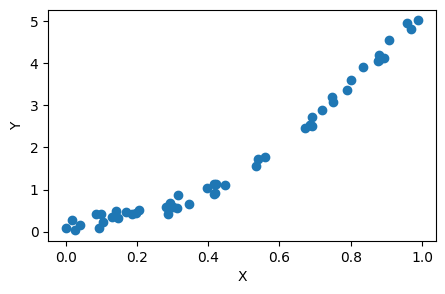

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
X = np.random.rand(50,1)
y = 0.7*(X**5) - \
    2.1*(X**4) + \
    2.7*(X**3) + \
    3.5*(X**2) + \
    0.3* X + \
    0.4*np.random.rand(50,1) # no data in world is perfect
fig = plt.figure(figsize=(5,3))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [9]:
X

array([[4.17022005e-01],
       [7.20324493e-01],
       [1.14374817e-04],
       [3.02332573e-01],
       [1.46755891e-01],
       [9.23385948e-02],
       [1.86260211e-01],
       [3.45560727e-01],
       [3.96767474e-01],
       [5.38816734e-01],
       [4.19194514e-01],
       [6.85219500e-01],
       [2.04452250e-01],
       [8.78117436e-01],
       [2.73875932e-02],
       [6.70467510e-01],
       [4.17304802e-01],
       [5.58689828e-01],
       [1.40386939e-01],
       [1.98101489e-01],
       [8.00744569e-01],
       [9.68261576e-01],
       [3.13424178e-01],
       [6.92322616e-01],
       [8.76389152e-01],
       [8.94606664e-01],
       [8.50442114e-02],
       [3.90547832e-02],
       [1.69830420e-01],
       [8.78142503e-01],
       [9.83468338e-02],
       [4.21107625e-01],
       [9.57889530e-01],
       [5.33165285e-01],
       [6.91877114e-01],
       [3.15515631e-01],
       [6.86500928e-01],
       [8.34625672e-01],
       [1.82882773e-02],
       [7.50144315e-01],


In [2]:
def adj_r(r_sq,X,Y):
  adj_r1 = (1 - ((1-r_sq)*(len(Y)-1))/(len(Y)-X.shape[1]-1) )
  return adj_r1

def r2_score(y,y_):
    num = np.sum((y-y_)**2)
    denom = np.sum((y- y.mean())**2)
    score = (1- num/denom)
    return score


# Trying different order of features

## Fitting our Linear model

In [3]:
from sklearn.linear_model import LinearRegression



model = LinearRegression()
model.fit(X, y)

output_1 = model.predict(X)
print('R2 score: ', r2_score(y, output_1))

R2 score:  0.9345996128366808


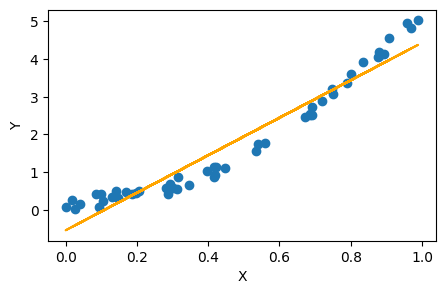

In [4]:
fig = plt.figure(figsize=(5,3))
plt.scatter(X, y, label="samples")
plt.plot(X, output_1, label="prediction",color='orange')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Trying order 2

In [5]:
# Adding X^2 as a feature

X_deg2 = np.hstack([X, X**2])
X_deg2[:5]

array([[4.17022005e-01, 1.73907352e-01],
       [7.20324493e-01, 5.18867376e-01],
       [1.14374817e-04, 1.30815988e-08],
       [3.02332573e-01, 9.14049845e-02],
       [1.46755891e-01, 2.15372915e-02]])

Adj. R-square: 0.9947910474710182


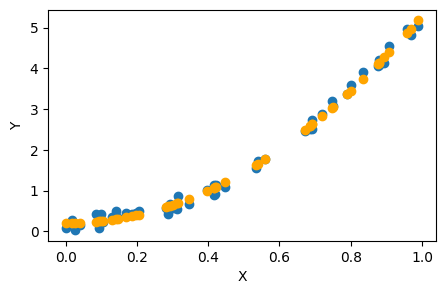

In [6]:
X_deg2 = np.hstack([X, X**2])
X_deg2[:5]

model_deg2 = LinearRegression()
model_deg2.fit(X_deg2, y)
output = model_deg2.predict(X_deg2)

print('Adj. R-square:', adj_r(r2_score(y,output),X,y ) )
fig = plt.figure(figsize=(5,3))
plt.scatter(X, y, label="samples")
plt.scatter(X, output, label="prediction",color='orange')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
model_deg2.coef_

## Easier way is to use PolynomialFeatures from Sklean preprocessing

In [7]:
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(2)

X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.00000000e+00, 4.17022005e-01, 1.73907352e-01],
       [1.00000000e+00, 7.20324493e-01, 5.18867376e-01],
       [1.00000000e+00, 1.14374817e-04, 1.30815988e-08],
       [1.00000000e+00, 3.02332573e-01, 9.14049845e-02],
       [1.00000000e+00, 1.46755891e-01, 2.15372915e-02]])

## Iteratively checking for each order of X, and corresponding R2 Score

Adj. R-square for Model Degree1: 0.9318166176382416


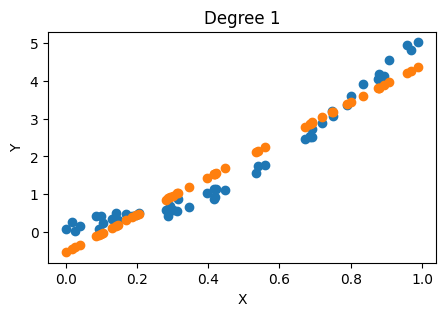

Adj. R-square for Model Degree2: 0.994564571274106


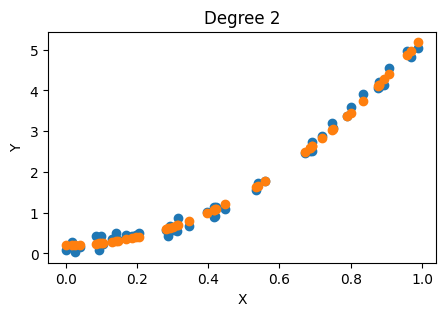

Adj. R-square for Model Degree3: 0.9944735532438161


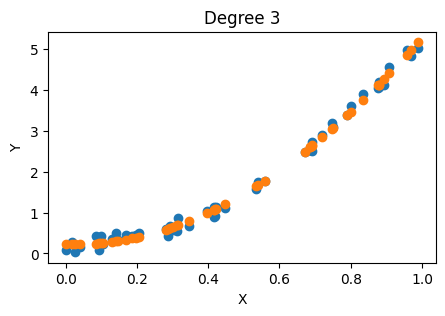

Adj. R-square for Model Degree4: 0.9954971261912255


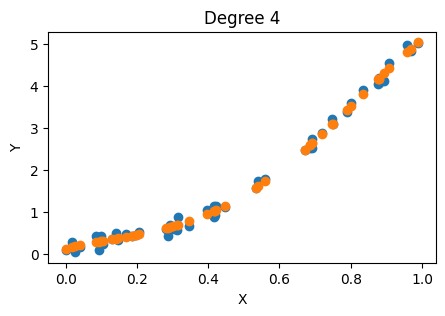

Adj. R-square for Model Degree5: 0.995442243943045


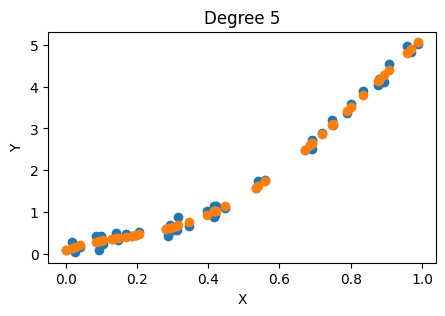

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

scores = []


# using degree 1 to 5
for i in range(1, 6):
  poly = PolynomialFeatures(i)

  X_poly = poly.fit_transform(X)

  scaler = StandardScaler()
  scaler.fit(X_poly)
  X_poly_scaled = scaler.transform(X_poly)


  #training model
  model = LinearRegression()
  model.fit(X_poly_scaled, y)

  #Prediction
  output = model.predict(X_poly_scaled)

  #Plotting
  value = adj_r(r2_score(y,output),X_poly_scaled,y )
  print(f'Adj. R-square for Model Degree{i}: {value}' )


  scores.append(value)

  fig = plt.figure(figsize=(5,3))
  plt.scatter(X, y, label="samples")
  plt.scatter(X, output, label="prediction")
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.title(f"Degree {i}")
  plt.show()



In [ ]:
scores

# Code for Underfitting/Overfitting

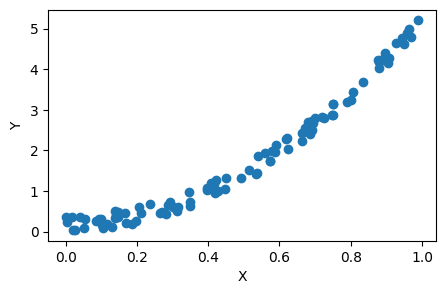

In [11]:
# lets first generate a dataset of 100 points this time
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
X = np.random.rand(100,1)
y = 0.7*(X**5) - \
    2.1*(X**4) + \
    2.7*(X**3) + \
    3.5*(X**2) + \
    0.3* X + \
    0.4*np.random.rand(100,1)

fig = plt.figure(figsize=(5,3))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

degrees = 100 # number of data-points
train_scores = []
test_scores = []

train_loss = []
test_loss = []

scaler = StandardScaler()

for degree in range(1, degrees):

  poly = PolynomialFeatures(degree)

  X_poly_train = poly.fit_transform(X_train)
  X_poly_test = poly.fit_transform(X_test)

  scaler.fit(X_poly_train)
  X_poly_scaled_train = scaler.transform(X_poly_train)
  X_poly_scaled_test = scaler.transform(X_poly_test)

  #training model
  polyreg_scaled = LinearRegression()
  polyreg_scaled.fit(X_poly_scaled_train, y_train)

  train_score = polyreg_scaled.score(X_poly_scaled_train, y_train)
  test_score = polyreg_scaled.score(X_poly_scaled_test, y_test)

  train_scores.append(train_score)
  test_scores.append(test_score)

  output1 = polyreg_scaled.predict(X_poly_scaled_train)
  output2 = polyreg_scaled.predict(X_poly_scaled_test)

  train_loss.append(mean_squared_error(y_train,output1))
  test_loss.append(mean_squared_error(y_test,output2))




In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(list(range(1, 100)), train_scores, label="train")
axes[0].plot(list(range(1, 100)), test_scores, label="test")
axes[0].legend(loc='lower right')
axes[0].set_xlabel("degree")
axes[0].set_ylabel("Adj.R-score")

axes[1].plot(list(range(1, 100)), train_loss, label="train")
axes[1].plot(list(range(1, 100)), test_loss, label="test")
axes[1].legend(loc='upper left')
axes[1].set_xlabel("degree")
axes[1].set_ylabel("MSE")

plt.show()